In [1]:
!pip install pandas scikit-learn matplotlib textblob

In [2]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abish\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Candidate Dataset


,Resume,Experience,Projects,Hired
0,Python pandas machine learning projects SQL,2,3,1
1,Java web development spring boot,1,1,0
2,Python AI deep learning tensorflow projects,3,4,1
3,HTML CSS basic website,0,0,0
4,Python data analysis matplotlib statistics,2,2,1



Skill Match Percentage


,Resume,Skill_Match
0,Python pandas machine learning projects SQL,29.61
1,Java web development spring boot,0.00
2,Python AI deep learning tensorflow projects,15.76
3,HTML CSS basic website,0.00
4,Python data analysis matplotlib statistics,20.55



Risk Levels


,Resume,Risk_Level
0,Python pandas machine learning projects SQL,Low
1,Java web development spring boot,Low
2,Python AI deep learning tensorflow projects,Low
3,HTML CSS basic website,High
4,Python data analysis matplotlib statistics,Low



Final Hiring Intelligence


,Skill_Match,Success_Probability,Risk_Level,AI_Decision
0,29.61,95.0,Low,Strong Candidate
1,0.00,12.0,Low,Reject
2,15.76,96.0,Low,Strong Candidate
3,0.00,6.0,High,Reject
4,20.55,88.0,Low,Strong Candidate


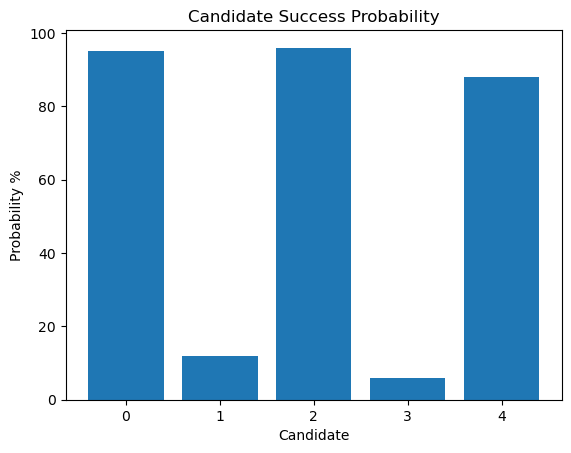


NEW CANDIDATE RESULT
Skill Match: 91.6 %
Success Probability: 88.0 %
AI Recommendation: Proceed to Interview


C:\Users\abish\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from textblob import TextBlob

# -------------------------------------------------
# SAMPLE DATA (Simulated candidates)
# -------------------------------------------------

data = {
    "Resume": [
        "Python pandas machine learning projects SQL",
        "Java web development spring boot",
        "Python AI deep learning tensorflow projects",
        "HTML CSS basic website",
        "Python data analysis matplotlib statistics"
    ],
    "Experience": [2, 1, 3, 0, 2],
    "Projects": [3, 1, 4, 0, 2],
    "Hired": [1, 0, 1, 0, 1]   # Training labels (1 = success)
}

df = pd.DataFrame(data)

job_description = "Looking for python machine learning data science candidate"

print("Candidate Dataset")
display(df)

# -------------------------------------------------
# NLP SKILL MATCHING (TF-IDF)
# -------------------------------------------------

documents = df["Resume"].tolist()
documents.append(job_description)

vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(documents)

similarity = cosine_similarity(tfidf[-1], tfidf[:-1])[0]
df["Skill_Match"] = (similarity * 100).round(2)

print("\nSkill Match Percentage")
display(df[["Resume","Skill_Match"]])

# -------------------------------------------------
# SIMPLE RISK ANALYSIS
# -------------------------------------------------

def risk_score(resume, projects):
    score = 0
    if len(resume.split()) < 5:
        score += 2
    if projects < 1:
        score += 2
    polarity = TextBlob(resume).sentiment.polarity
    if polarity < 0:
        score += 1
    return score

df["Risk"] = df.apply(lambda x: risk_score(x["Resume"],x["Projects"]),axis=1)

def risk_level(x):
    if x >=3:
        return "High"
    elif x==2:
        return "Medium"
    else:
        return "Low"

df["Risk_Level"] = df["Risk"].apply(risk_level)

print("\nRisk Levels")
display(df[["Resume","Risk_Level"]])

# -------------------------------------------------
# MACHINE LEARNING SUCCESS PREDICTION
# -------------------------------------------------

X = df[["Skill_Match","Experience","Projects","Risk"]]
y = df["Hired"]

model = RandomForestClassifier()
model.fit(X,y)

df["Success_Probability"] = (model.predict_proba(X)[:,1]*100).round(2)

# -------------------------------------------------
# FINAL AI RECOMMENDATION
# -------------------------------------------------

def recommend(row):
    if row["Success_Probability"]>70 and row["Risk_Level"]=="Low":
        return "Strong Candidate"
    elif row["Success_Probability"]>50:
        return "Shortlist"
    else:
        return "Reject"

df["AI_Decision"] = df.apply(recommend,axis=1)

print("\nFinal Hiring Intelligence")
display(df[["Skill_Match","Success_Probability","Risk_Level","AI_Decision"]])

# -------------------------------------------------
# VISUALIZATION
# -------------------------------------------------

plt.figure()
plt.bar(range(len(df)),df["Success_Probability"])
plt.title("Candidate Success Probability")
plt.xlabel("Candidate")
plt.ylabel("Probability %")
plt.show()

# -------------------------------------------------
# SINGLE CANDIDATE TEST
# -------------------------------------------------

new_resume = "python machine learning pandas project sql"

vec = vectorizer.transform([new_resume])
match = cosine_similarity(vec, tfidf[:-1]).max()*100

new_features = [[match,2,2,0]]
pred = model.predict_proba(new_features)[0][1]*100

print("\nNEW CANDIDATE RESULT")
print("Skill Match:",round(match,2),"%")
print("Success Probability:",round(pred,2),"%")

if pred>70:
    print("AI Recommendation: Proceed to Interview")
elif pred>50:
    print("AI Recommendation: Technical Round")
else:
    print("AI Recommendation: Reject")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from textblob import TextBlob

# -------------------------------------------------
# SAMPLE CANDIDATE DATASET
# -------------------------------------------------

data = {
    "Resume": [
        "Python pandas machine learning projects SQL",
        "Java web development spring boot",
        "Python AI deep learning tensorflow projects",
        "HTML CSS basic website",
        "Python data analysis matplotlib statistics"
    ],
    "Experience": [2, 1, 3, 0, 2],
    "Projects": [3, 1, 4, 0, 2],
    "Hired": [1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)

job_description = "Looking for python machine learning data science candidate"

print("Candidate Dataset")
display(df)

# -------------------------------------------------
# NLP SKILL MATCHING
# -------------------------------------------------

documents = df["Resume"].tolist()
documents.append(job_description)

vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(documents)

similarity = cosine_similarity(tfidf[-1], tfidf[:-1])[0]
df["Skill_Match"] = (similarity * 100).round(2)

print("\nSkill Match Percentage")
display(df[["Resume","Skill_Match"]])

# -------------------------------------------------
# RISK ANALYSIS
# -------------------------------------------------

def risk_score(resume, projects):
    score = 0
    if len(resume.split()) < 5:
        score += 2
    if projects < 1:
        score += 2
    polarity = TextBlob(resume).sentiment.polarity
    if polarity < 0:
        score += 1
    return score

df["Risk"] = df.apply(lambda x: risk_score(x["Resume"],x["Projects"]),axis=1)

def risk_level(x):
    if x >=3:
        return "High"
    elif x==2:
        return "Medium"
    else:
        return "Low"

df["Risk_Level"] = df["Risk"].apply(risk_level)

print("\nRisk Levels")
display(df[["Resume","Risk_Level"]])

# -------------------------------------------------
# MACHINE LEARNING MODEL
# -------------------------------------------------

X = df[["Skill_Match","Experience","Projects","Risk"]]
y = df["Hired"]

model = RandomForestClassifier()
model.fit(X,y)

df["Success_Probability"] = (model.predict_proba(X)[:,1]*100).round(2)

# -------------------------------------------------
# AI DECISION ENGINE
# -------------------------------------------------

def recommend(row):
    if row["Success_Probability"]>70 and row["Risk_Level"]=="Low":
        return "Strong Candidate"
    elif row["Success_Probability"]>50:
        return "Shortlist"
    else:
        return "Reject"

df["AI_Decision"] = df.apply(recommend,axis=1)

print("\nFinal Hiring Intelligence")
display(df[["Skill_Match","Success_Probability","Risk_Level","AI_Decision"]])

# -------------------------------------------------
# VISUALIZATION
# -------------------------------------------------

plt.figure()
plt.bar(range(len(df)),df["Success_Probability"])
plt.title("Candidate Success Probability")
plt.xlabel("Candidate")
plt.ylabel("Probability %")
plt.show()

# -------------------------------------------------
# NEW CANDIDATE TEST (FIXED VERSION)
# -------------------------------------------------

new_resume = "python machine learning pandas project sql"

vec = vectorizer.transform([new_resume])
match = cosine_similarity(vec, tfidf[:-1]).max()*100

new_features = pd.DataFrame(
    [[match,2,2,0]],
    columns=["Skill_Match","Experience","Projects","Risk"]
)

pred = model.predict_proba(new_features)[0][1]*100

print("\nNEW CANDIDATE RESULT")
print("Skill Match:",round(match,2),"%")
print("Success Probability:",round(pred,2),"%")

if pred>70:
    print("AI Recommendation: Proceed to Interview")
elif pred>50:
    print("AI Recommendation: Technical Round")
else:
    print("AI Recommendation: Reject")